In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_ROOT = "/content/drive/MyDrive/smear2005"
SPLIT_ROOT = "/content/drive/MyDrive/smear_split"

def split_dataset():
    classes = os.listdir(DATA_ROOT)

    for cls in classes:
        images = os.listdir(os.path.join(DATA_ROOT, cls))
        random.shuffle(images)

        train_split = int(0.7 * len(images))
        val_split   = int(0.85 * len(images))

        splits = {
            "train": images[:train_split],
            "val": images[train_split:val_split],
            "test": images[val_split:]
        }

        for split in splits:
            split_path = os.path.join(SPLIT_ROOT, split, cls)
            os.makedirs(split_path, exist_ok=True)

            for img in splits[split]:
                src = os.path.join(DATA_ROOT, cls, img)
                dst = os.path.join(split_path, img)

                if not os.path.exists(dst):
                    shutil.copy(src, dst)

# Run only once
#split_dataset()

In [ ]:
from torchvision import transforms

# Vision Transformer Transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ViT standard input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
import os

def get_dataloaders(data_root, batch_size=16):

    train_dir = os.path.join(data_root, "train")
    val_dir   = os.path.join(data_root, "val")
    test_dir  = os.path.join(data_root, "test")

    train_data = datasets.ImageFolder(train_dir, transform=train_transform)
    val_data   = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_data  = datasets.ImageFolder(test_dir, transform=val_test_transform)

    train_loader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 7

# Load pretrained Vision Transformer
model = models.vit_b_16(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last encoder blocks
for param in model.encoder.layers[-2:].parameters():
    param.requires_grad = True

# Replace classification head
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

# Move model to device
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 60.6MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Optimizer for ViT
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=20):

    best_val_acc = 0

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for imgs, labels in train_loader:

            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        val_acc = evaluate(model, val_loader, print_result=False)

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(model.state_dict(), "vit_best.pth")

            print("✅ ViT Model Saved!")

        print("-" * 30)

In [ ]:
def evaluate(model, loader, print_result=True):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for imgs, labels in loader:

            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    acc = 100 * correct / total

    if print_result:
        print(f"Accuracy: {acc:.2f}%")

    return acc

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(SPLIT_ROOT)

train_model(model, train_loader, val_loader, epochs=20)

print("🔍 Loading Best Model...")

model.load_state_dict(torch.load("vit_best.pth"))

print("Validation:")
evaluate(model, val_loader)

print("Test:")
evaluate(model, test_loader)

Epoch 1
Train Loss: 1.7303
Val Accuracy: 43.06%
✅ ViT Model Saved!
------------------------------
Epoch 2
Train Loss: 1.3864
Val Accuracy: 52.85%
✅ ViT Model Saved!
------------------------------
Epoch 3
Train Loss: 1.1760
Val Accuracy: 60.24%
✅ ViT Model Saved!
------------------------------
Epoch 4
Train Loss: 1.0438
Val Accuracy: 63.34%
✅ ViT Model Saved!
------------------------------
Epoch 5
Train Loss: 0.9523
Val Accuracy: 64.74%
✅ ViT Model Saved!
------------------------------
Epoch 6
Train Loss: 0.8878
Val Accuracy: 67.63%
✅ ViT Model Saved!
------------------------------
Epoch 7
Train Loss: 0.8393
Val Accuracy: 70.13%
✅ ViT Model Saved!
------------------------------
Epoch 8
Train Loss: 0.7772
Val Accuracy: 73.13%
✅ ViT Model Saved!
------------------------------
Epoch 9
Train Loss: 0.7432
Val Accuracy: 71.93%
------------------------------
Epoch 10
Train Loss: 0.6976
Val Accuracy: 75.32%
✅ ViT Model Saved!
------------------------------
Epoch 11
Train Loss: 0.6487
Val Accura

86.69201520912547

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

def get_attention_map(model, x):

    attentions = []

    def hook_fn(module, input, output):

        qkv = module.in_proj_weight

        attentions.append(output)

    hooks = []

    for block in model.encoder.layers:
        hooks.append(
            block.self_attention.register_forward_hook(hook_fn)
        )

    with torch.no_grad():
        _ = model(x)

    for h in hooks:
        h.remove()

    return attentions


def apply_attention_rollout(
    model,
    loader,
    device,
    num_images=5,
    save_path="attention_rollout/"
):

    model.eval()

    os.makedirs(save_path, exist_ok=True)

    count = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)

        for i in range(imgs.size(0)):

            if count >= num_images:
                return

            input_tensor = imgs[i].unsqueeze(0)

            with torch.no_grad():

                outputs = model(input_tensor)

                probs = torch.softmax(outputs, dim=1)

                pred_class = torch.argmax(probs, dim=1).item()

                conf = probs[0, pred_class].item()

            # Forward features manually
            x = model._process_input(input_tensor)

            n = x.shape[0]

            batch_class_token = model.class_token.expand(n, -1, -1)

            x = torch.cat([batch_class_token, x], dim=1)

            attention_maps = []

            for blk in model.encoder.layers:

                # attention forward
                attn_output, attn_weights = blk.self_attention(
                    x, x, x,
                    need_weights=True,
                    average_attn_weights=False
                )

                attention_maps.append(attn_weights)

                x = blk(x)

            # Rollout
            result = torch.eye(attention_maps[0].size(-1)).to(device)

            for attention in attention_maps:

                attention_heads_fused = attention.mean(dim=1)[0]

                attention_heads_fused += torch.eye(
                    attention_heads_fused.size(-1)
                ).to(device)

                attention_heads_fused /= attention_heads_fused.sum(dim=-1, keepdim=True)

                result = torch.matmul(attention_heads_fused, result)

            # CLS token attention
            mask = result[0, 1:]

            num_patches = int(mask.size(0) ** 0.5)

            mask = mask.reshape(num_patches, num_patches).detach().cpu().numpy()

            # Normalize
            mask = (mask - mask.min()) / (mask.max() + 1e-8)

            mask = cv2.resize(mask, (224, 224))

            # Original image
            img = imgs[i].cpu().numpy().transpose(1, 2, 0)

            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])

            img = std * img + mean

            img = np.clip(img, 0, 1)

            # Plot
            plt.figure(figsize=(6,6))

            plt.imshow(img)

            plt.imshow(mask, cmap='jet', alpha=0.5)

            plt.title(
                f"True: {labels[i].item()} | Pred: {pred_class} | Conf: {conf:.2f}"
            )

            plt.axis("off")

            plt.savefig(f"{save_path}attention_{count}.png")

            plt.show()

            count += 1

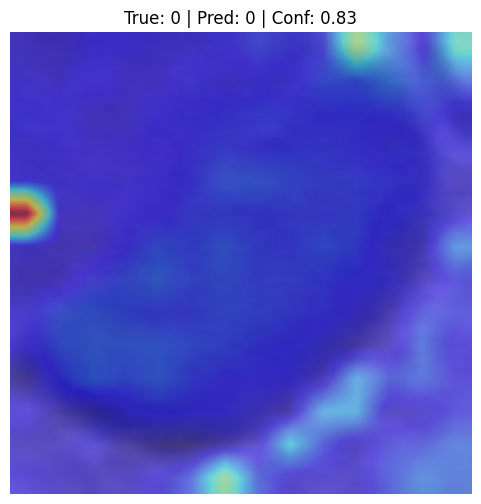

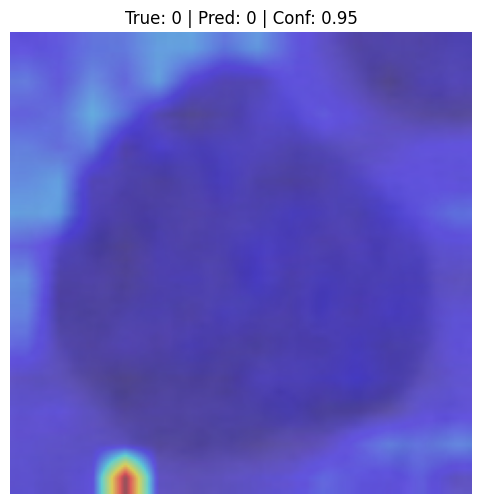

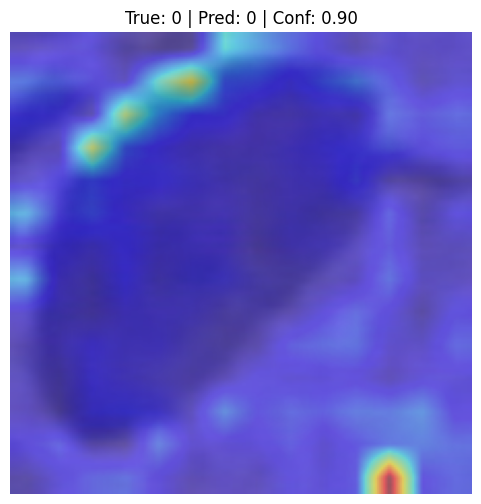

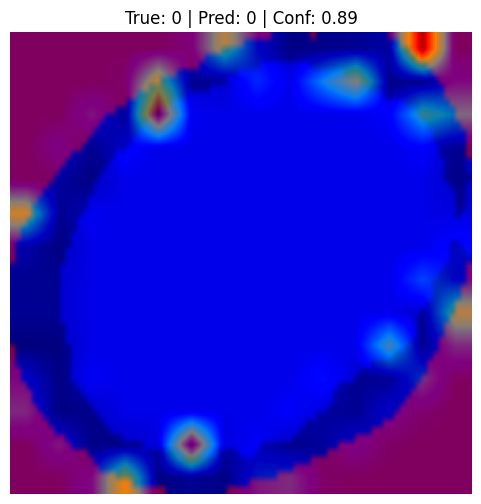

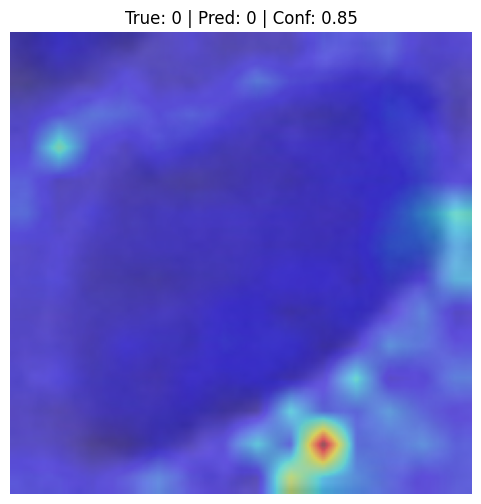

In [ ]:
apply_attention_rollout(model, test_loader, device)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np
import torch


def evaluate_metrics(model, loader, class_names):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    print("\n📊 Classification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(cmap="Blues", xticks_rotation=45)

    plt.title("Confusion Matrix")

    plt.show()


📊 Classification Report:

                     precision    recall  f1-score   support

  carcinoma_in_situ     0.8720    0.8512    0.8614       168
   light_dysplastic     0.9368    0.8517    0.8922       209
moderate_dysplastic     0.8428    0.7976    0.8196       168
    normal_columnar     0.8761    0.9000    0.8879       110
normal_intermediate     1.0000    0.8861    0.9396        79
 normal_superficiel     0.9053    1.0000    0.9503        86
  severe_dysplastic     0.7739    0.8707    0.8195       232

           accuracy                         0.8669      1052
          macro avg     0.8867    0.8796    0.8815      1052
       weighted avg     0.8713    0.8669    0.8675      1052



<Figure size 800x800 with 0 Axes>

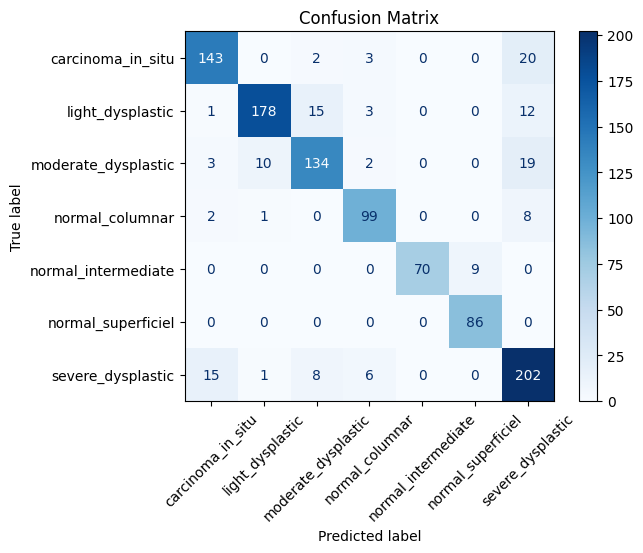

In [ ]:
class_names = train_loader.dataset.classes

evaluate_metrics(model, test_loader, class_names)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

In [ ]:
num_classes = len(class_names)

# Convert labels to one-hot format
all_labels_bin = label_binarize(all_labels, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        all_labels_bin[:, i],
        all_probs[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

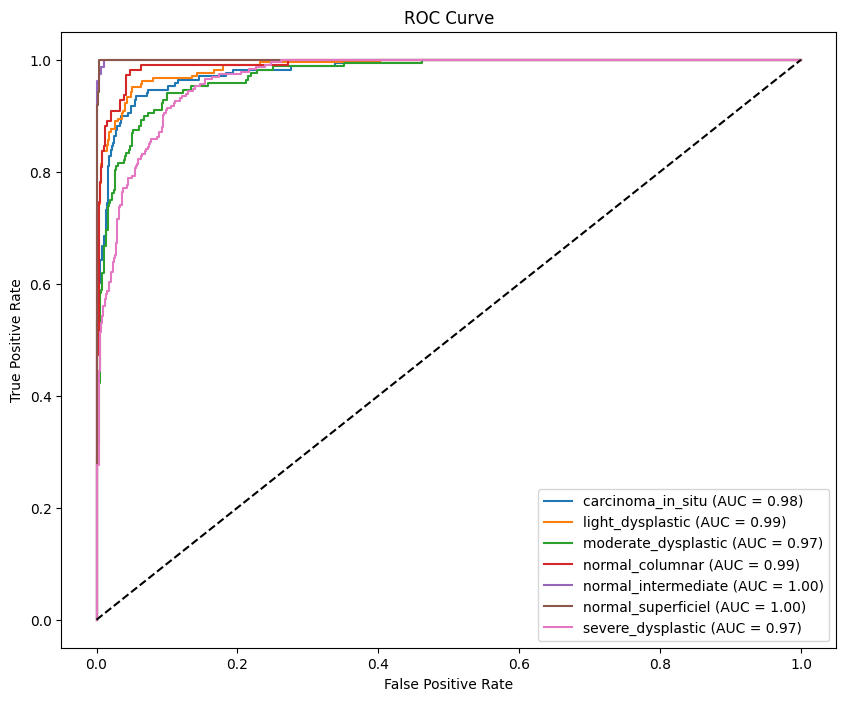

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig("roc_curve_vit.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    np.argmax(all_probs, axis=1),
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

                     precision    recall  f1-score     support
carcinoma_in_situ     0.871951  0.851190  0.861446   168.00000
light_dysplastic      0.936842  0.851675  0.892231   209.00000
moderate_dysplastic   0.842767  0.797619  0.819572   168.00000
normal_columnar       0.876106  0.900000  0.887892   110.00000
normal_intermediate   1.000000  0.886076  0.939597    79.00000
normal_superficiel    0.905263  1.000000  0.950276    86.00000
severe_dysplastic     0.773946  0.870690  0.819473   232.00000
accuracy              0.866920  0.866920  0.866920     0.86692
macro avg             0.886697  0.879607  0.881498  1052.00000
weighted avg          0.871343  0.866920  0.867514  1052.00000


In [ ]:
report_df.to_csv("classification_report_vit.csv")

In [ ]:
import os
from torchvision.utils import save_image

error_dir = "/content/drive/MyDrive/misclassified_samples_vit"
os.makedirs(error_dir, exist_ok=True)

model.eval()

with torch.no_grad():

    count = 0

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):

            if preds[i] != labels[i]:

                true_label = class_names[labels[i]]
                pred_label = class_names[preds[i]]

                save_path = os.path.join(
                    error_dir,
                    f"true_{true_label}_pred_{pred_label}_{count}.png"
                )

                save_image(images[i].cpu(), save_path)

                count += 1